### 🧠 XGBoost for **Classification** – In-Depth Explanation

---

## 🧩 1. Problem Setup

Given a dataset:

* Features: $X \in \mathbb{R}^{n \times d}$
* Labels: $y \in \{0, 1\}$ (for binary classification)

Your goal is to predict:

```math
\hat{y}_i = \mathbb{P}(y_i = 1 \mid x_i)
```

---

## 🔹 2. Model Structure (Same as Regression)

XGBoost still builds an **additive ensemble of decision trees**:

```math
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)
```

However, in **classification**, the model learns **log-odds**:

```math
f_t(x_i) ≈ \text{logit}(p_i) = \log\left( \frac{p_i}{1 - p_i} \right)
```

The probability is then recovered as:

```math
p_i = \sigma(\hat{y}_i) = \frac{1}{1 + e^{-\hat{y}_i}}
```

---

## 🔹 3. Loss Function: Logistic Loss

For binary classification, the loss is:

```math
\mathcal{L} = - \sum_{i=1}^{n} \left[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \right]
```

### First-order gradient:

```math
g_i = \hat{p}_i - y_i
```

### Second-order hessian:

```math
h_i = \hat{p}_i (1 - \hat{p}_i)
```

> These gradients and hessians are used to **fit the next tree**.

---

## 🔹 4. Tree Construction (Same as Regression)

At every split, XGBoost:

* Aggregates gradients & hessians
* Computes **gain** for each possible split:

```math
\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
```

Whichever **feature + split value** gives the best gain → that’s used to split the node.

---

## 🔹 5. Final Prediction

Once all trees are built:

1. Model outputs:

   ```math
   \hat{y} = \sum_t f_t(x)
   ```

2. Probability (for binary):

   ```math
   p = \sigma(\hat{y})
   ```

3. Final label:

   ```python
   y_pred = 1 if p > 0.5 else 0
   ```

---

## 🔹 6. Multiclass Classification

XGBoost also supports **multiclass**:

### Objective: `multi:softprob`

* Learns **one tree per class** per iteration
* Outputs a probability vector for all classes

```python
model = XGBClassifier(objective='multi:softprob', num_class=3)
```

---

## ✅ Example (Binary Classification)

```python
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier(objective='binary:logistic')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
```

---

## 🔸 Summary Table

| Component          | Binary Classification     |
| ------------------ | ------------------------- |
| Loss Function      | Logistic loss             |
| Output per Tree    | Log-odds                  |
| Final Output       | Sigmoid of total log-odds |
| Decision Threshold | 0.5                       |
| Gradient           | $\hat{p} - y$             |
| Hessian            | $\hat{p}(1 - \hat{p})$    |

---



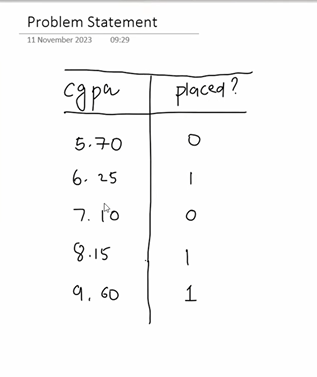

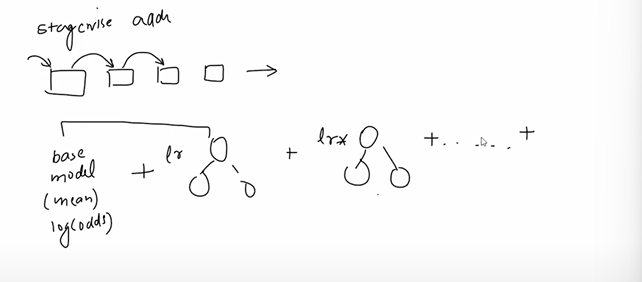

Additive modeling

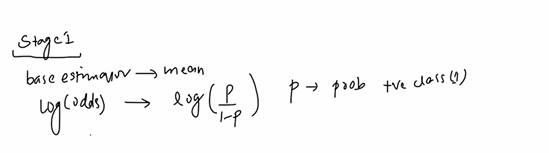

Odds= p/(1-p)
where p=probability of positive class

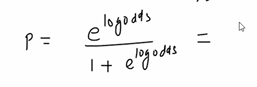

Get the probability from it

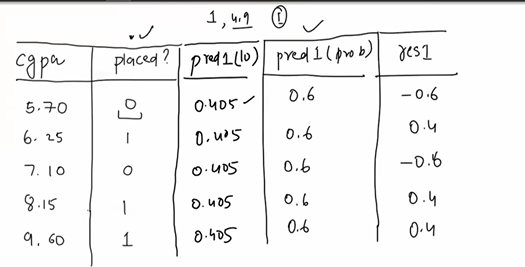

Calculate residual1

### How are the decision trees between the input features and the residuals made?

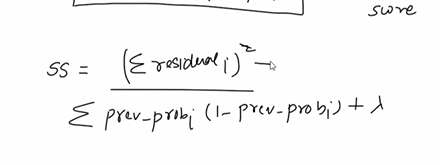

Similarity score

### 🌳 Similarity Score in XGBoost Decision Trees (Used to Split Nodes)

---

In XGBoost, **similarity score** is a key quantity that measures how “pure” a node is — it's used to:

* Decide if a node should be split
* Compute **gain** from the split
* Assign **leaf weights**

---

## 🔹 Definition: Similarity Score of a Node

For a node containing samples with gradient $g_i$ and hessian $h_i$, the **similarity score** is:

```math
\text{Similarity} = \frac{G^2}{H + \lambda}
```

Where:

* $G = \sum_{i \in \text{node}} g_i$ = sum of gradients
* $H = \sum_{i \in \text{node}} h_i$ = sum of hessians
* $\lambda$ = L2 regularization term

---

## 🔸 Intuition

* High similarity ⇒ gradients point in the **same direction**, meaning the node is **homogeneous** and easy to fit.
* Low similarity ⇒ conflicting gradients, node is **mixed** or noisy.

So, a high similarity score suggests the node is a good candidate for a **leaf** or can be **further split** to get better performance.

---

## 🔹 Example

Assume a node with 3 samples having:

| Sample | Gradient $g_i$ | Hessian $h_i$ |
| ------ | -------------- | ------------- |
| 1      | 1.5            | 1.0           |
| 2      | 1.2            | 1.0           |
| 3      | 1.3            | 1.0           |

Compute:

* $G = 1.5 + 1.2 + 1.3 = 4.0$
* $H = 1 + 1 + 1 = 3.0$
* Let $\lambda = 1$

Then:

```math
\text{Similarity} = \frac{4.0^2}{3 + 1} = \frac{16}{4} = 4.0
```

✅ A similarity score of **4.0** means the node is pure enough to either stop splitting (make a leaf), or compare against other candidate splits.

---

## 🔹 Usage in Tree Building

When evaluating a **split**, we compute the **gain**:

```math
\text{Gain} = \text{Similarity}_{\text{left}} + \text{Similarity}_{\text{right}} - \text{Similarity}_{\text{parent}} - \gamma
```

* $\gamma$ = minimum gain required to make a split

If gain > 0 ⇒ perform the split
Otherwise ⇒ stop and make a **leaf node**

---

## 🔸 Summary Table

| Term         | Formula                          | Meaning                               |
| ------------ | -------------------------------- | ------------------------------------- |
| Gradient $G$ | $\sum g_i$                       | Total residual error                  |
| Hessian $H$  | $\sum h_i$                       | Total curvature                       |
| Similarity   | $\frac{G^2}{H + \lambda}$        | Node “purity” score                   |
| Gain (split) | Left + Right – Parent – $\gamma$ | Improvement in objective by splitting |

---



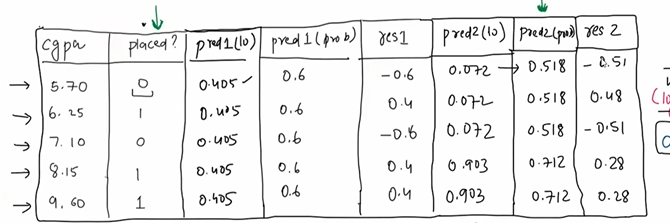